In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches 
import matplot2tikz as tikz 
import shutil
import collections

from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import rbf_kernel as rbf
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from scipy.special import gamma, kv
from scipy.signal import savgol_filter

from time import perf_counter
from reml import NadarayaWatsonClassifier, DyadicNWC, LocalizedNWC
from baselines import LocalPolynomialClassifier

rng = np.random.default_rng(seed=None)

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update(
    {
        'text.usetex': True
    }
)

In [3]:
CONFIG = {
    "data": {
        "num_train": 87554,
        "lipschitz_constant": 0.05
    },
    "kernel": {
        "bandwidth": 0.75
    },
    "evaluation": {
        "num_test": 10, 
        "acc_test": 500,
        "dyadic_m": 5, 
        "localized_k": 10
    }
}

In [4]:
# NOTE: AISTATS paper dimensions 
page_width_pt = 487.8225 
column_width_pt = 234.8775

def set_figure_size(width_pt, fraction=0.9, subplots=(1, 1)):
    fig_width_pt = width_pt * fraction
    inches_per_pt = 1 / 72.27

    golden_ratio = (5**0.5 - 1) / 2

    fig_width_in = fig_width_pt * inches_per_pt
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

base_figure_size = set_figure_size(page_width_pt, 0.9, (1, 1))

# Loading Training Data

Here we want to try a few variations to see how the nature of the data affects the classifier's performance. 

1. Training on the data as-is. 
2. Training on a balanced set of the data. 
   1. By having a large number of training points as binary classification
      1. Here, we will also train a second classifier on the unbalanced minority 'abnormal' set.
   2. By having a smaller number of training points my matching sample sizes to the lowest training set size 
   3. Using synthetic minority oversampling technique, commonly known as SMOTE. 

## I. Training on the data as-is. 

In [5]:
def load_ecg_data(n_train, n_test, stratified=True):
    """
    Loads, preprocesses, and samples the MIT-BIH ECG dataset.
    """
    # Load data from CSV files
    try:
        mitbih_train_df = pd.read_csv('./data/ecg_heartbeat_dataset/mitbih_train.csv', header=None)
        mitbih_test_df = pd.read_csv('./data/ecg_heartbeat_dataset/mitbih_test.csv', header=None)
    except FileNotFoundError:
        print("Error: Dataset files not found.")
        print("Please ensure 'mitbih_train.csv' and 'mitbih_test.csv' are in the './data/ecg_heartbeat_dataset/' directory.")
        return None

    # --- Training Data ---
    # Stratified sampling to handle class imbalance
    train_df_sampled = mitbih_train_df.groupby(187, group_keys=False).apply(lambda x: x.sample(int(np.rint(n_train * len(x) / len(mitbih_train_df))))).sample(frac=1).reset_index(drop=True)

    x_train_raw = train_df_sampled.iloc[:, :-1].values
    y_train = train_df_sampled.iloc[:, -1].values.astype(int)

    if stratified:
        # --- Test Data, stratified sampling ---
        # Stratified sampling to ensure all classes are represented in the test set
        # We want at least one of each class, if available
        test_indices = []
        for class_id in range(5): # 5 classes in this dataset
            class_indices = mitbih_test_df[mitbih_test_df[187] == class_id].index
            if not class_indices.empty:
                test_indices.extend(rng.choice(class_indices, min(len(class_indices), n_test // 5), replace=False))

        # Fill remaining spots if needed
        remaining_needed = n_test - len(test_indices)
        if remaining_needed > 0:
            remaining_indices = mitbih_test_df.index.difference(test_indices)
            test_indices.extend(rng.choice(remaining_indices, remaining_needed, replace=False))
        
        test_df_sampled = mitbih_test_df.loc[test_indices]
        x_test_raw = test_df_sampled.iloc[:, :-1].values
        y_test = test_df_sampled.iloc[:, -1].values.astype(int)

    else:
        # ----- Test data, truly random ----
        test_indices = rng.choice(mitbih_test_df.index, n_test, replace=False)
        test_df_sampled = mitbih_test_df.loc[test_indices]
        x_test_raw = test_df_sampled.iloc[:, :-1].values
        y_test = test_df_sampled.iloc[:, -1].values.astype(int)

    # --- Scaling ---
    # Scale features to be between 0 and 1
    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train_raw)
    x_test = scaler.transform(x_test_raw)

    # --- One-Hot Encoding for Labels ---
    # The classifier expects labels in a one-hot format
    num_classes = 5
    y_train_one_hot = np.zeros((len(y_train), num_classes))
    y_train_one_hot[np.arange(len(y_train)), y_train] = 1
    
    print(f"Loaded {len(x_train)} training samples and {len(x_test)} testing samples.")
    print(f"Training data shape: {x_train.shape}")
    print(f"Test data shape: {x_test.shape}")
    
    return {
        'x_train': x_train,
        'y_train_one_hot': y_train_one_hot,
        'y_train_plain': y_train,
        'x_test': x_test,
        'y_test': y_test
    }

## II. A balanced binary classifier without oversampling 

Here, we would lump all abnormal heartbeats into one category. 

In [6]:
def load_ecg_binary_balanced(n_train, n_test, stratified=True):
    # NOTE: maximum for n_train is 30166 
    """
    Loads, preprocesses, and samples the MIT-BIH ECG dataset as a balanced binary classification problem.
    Class 0: Normal (label 0 in original data)
    Class 1: Abnormal (labels 1,2,3,4 in original data)
    Returns a balanced dataset with equal numbers of normal and abnormal beats.
    """
    try:
        mitbih_train_df = pd.read_csv('./data/ecg_heartbeat_dataset/mitbih_train.csv', header=None)
        mitbih_test_df = pd.read_csv('./data/ecg_heartbeat_dataset/mitbih_test.csv', header=None)
    except FileNotFoundError:
        print("Error: Dataset files not found.")
        print("Please ensure 'mitbih_train.csv' and 'mitbih_test.csv' are in the './data/ecg_heartbeat_dataset/' directory.")
        return None

    # Assign binary labels: 0 for normal, 1 for abnormal
    train_df = mitbih_train_df.copy()
    test_df = mitbih_test_df.copy()
    train_df['binary_label'] = (train_df[187] != 0).astype(int)
    test_df['binary_label'] = (test_df[187] != 0).astype(int)

    # Split into normal and abnormal
    normal_train = train_df[train_df['binary_label'] == 0]
    abnormal_train = train_df[train_df['binary_label'] == 1]

    # Determine the number of samples per class for balance
    n_per_class = min(len(normal_train), len(abnormal_train), n_train // 2)

    # Sample equal number from each class
    normal_train_sampled = normal_train.sample(n=n_per_class, random_state=42)
    abnormal_train_sampled = abnormal_train.sample(n=n_per_class, random_state=42)
    train_df_balanced = pd.concat([normal_train_sampled, abnormal_train_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

    x_train_raw = train_df_balanced.iloc[:, :-2].values  # exclude original and binary label columns
    y_train = train_df_balanced['binary_label'].values.astype(int)

    # --- Test Data ---
    if stratified:
        # Stratified: equal number from each class if possible
        normal_test = test_df[test_df['binary_label'] == 0]
        abnormal_test = test_df[test_df['binary_label'] == 1]
        n_per_class_test = min(len(normal_test), len(abnormal_test), n_test // 2)
        normal_test_sampled = normal_test.sample(n=n_per_class_test, random_state=42)
        abnormal_test_sampled = abnormal_test.sample(n=n_per_class_test, random_state=42)
        test_df_balanced = pd.concat([normal_test_sampled, abnormal_test_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)
        x_test_raw = test_df_balanced.iloc[:, :-2].values
        y_test = test_df_balanced['binary_label'].values.astype(int)
    else:
        # Random test samples (not necessarily balanced)
        test_indices = rng.choice(test_df.index, n_test, replace=False)
        x_test_raw = test_df.loc[test_indices].iloc[:, :-2].values
        y_test = test_df.loc[test_indices]['binary_label'].values.astype(int)

    # --- Scaling ---
    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train_raw)
    x_test = scaler.transform(x_test_raw)

    # --- One-Hot Encoding for Labels ---
    num_classes = 2
    y_train_one_hot = np.zeros((len(y_train), num_classes))
    y_train_one_hot[np.arange(len(y_train)), y_train] = 1

    print(f"Loaded {len(x_train)} balanced binary training samples and {len(x_test)} testing samples.")
    print(f"Training data shape: {x_train.shape}")
    print(f"Test data shape: {x_test.shape}")

    return {
        'x_train': x_train,
        'y_train_one_hot': y_train_one_hot,
        'y_train_plain': y_train,
        'x_test': x_test,
        'y_test': y_test
    }

## III. A balanced multi-class classifier without oversampling 

Here, we simply take exactly as many samples from each class as there are in the smallest minority instance. 

In [7]:
def load_ecg_multiclass_balanced(stratified=True):
    """
    Loads, preprocesses, and samples the MIT-BIH ECG dataset as a balanced multi-class classification problem.
    Each class will have the same number of samples as the smallest class in the training set.
    """
    try:
        mitbih_train_df = pd.read_csv('./data/ecg_heartbeat_dataset/mitbih_train.csv', header=None)
        mitbih_test_df = pd.read_csv('./data/ecg_heartbeat_dataset/mitbih_test.csv', header=None)
    except FileNotFoundError:
        print("Error: Dataset files not found.")
        print("Please ensure 'mitbih_train.csv' and 'mitbih_test.csv' are in the './data/ecg_heartbeat_dataset/' directory.")
        return None

    # --- Training Data: Balanced by smallest class ---
    class_counts = mitbih_train_df[187].value_counts()
    min_class_count = class_counts.min()
    balanced_train_samples = []
    for class_id in sorted(class_counts.index):
        class_samples = mitbih_train_df[mitbih_train_df[187] == class_id]
        balanced_train_samples.append(class_samples.sample(n=min_class_count, random_state=42))
    train_df_balanced = pd.concat(balanced_train_samples).sample(frac=1, random_state=42).reset_index(drop=True)

    x_train_raw = train_df_balanced.iloc[:, :-1].values
    y_train = train_df_balanced.iloc[:, -1].values.astype(int)

    # --- Test Data: Balanced by smallest class in test set ---
    class_counts_test = mitbih_test_df[187].value_counts()
    min_class_count_test = class_counts_test.min()
    balanced_test_samples = []
    for class_id in sorted(class_counts_test.index):
        class_samples = mitbih_test_df[mitbih_test_df[187] == class_id]
        balanced_test_samples.append(class_samples.sample(n=min_class_count_test, random_state=42))
    test_df_balanced = pd.concat(balanced_test_samples).sample(frac=1, random_state=42).reset_index(drop=True)

    x_test_raw = test_df_balanced.iloc[:, :-1].values
    y_test = test_df_balanced.iloc[:, -1].values.astype(int)

    # --- Scaling ---
    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train_raw)
    x_test = scaler.transform(x_test_raw)

    # --- One-Hot Encoding for Labels ---
    num_classes = len(class_counts)
    y_train_one_hot = np.zeros((len(y_train), num_classes))
    y_train_one_hot[np.arange(len(y_train)), y_train] = 1

    print(f"Loaded {len(x_train)} balanced multi-class training samples and {len(x_test)} balanced testing samples.")
    print(f"Training data shape: {x_train.shape}")
    print(f"Test data shape: {x_test.shape}")

    return {
        'x_train': x_train,
        'y_train_one_hot': y_train_one_hot,
        'y_train_plain': y_train,
        'x_test': x_test,
        'y_test': y_test
    }

## IV. A balanced multi-class classifier with Synthetic Minority Oversampling Technique (SMOTE)

Here we use SMOTE: https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html 

We can also use ADASYN -- intuitively I think we might end up with better performance but I'm gonna stash this idea for now. 

In [8]:
def load_ecg_multiclass_oversampled(n_train, n_test, stratified=True, random_state=None):
    """
    Loads, preprocesses, and samples the MIT-BIH ECG dataset as a balanced multi-class classification problem using SMOTE.
    Each class will have exactly n_train // 5 samples (oversampled if needed).
    """
    try:
        mitbih_train_df = pd.read_csv('./data/ecg_heartbeat_dataset/mitbih_train.csv', header=None)
        mitbih_test_df = pd.read_csv('./data/ecg_heartbeat_dataset/mitbih_test.csv', header=None)
    except FileNotFoundError:
        print("Error: Dataset files not found.")
        print("Please ensure 'mitbih_train.csv' and 'mitbih_test.csv' are in the './data/ecg_heartbeat_dataset/' directory.")
        return None

    # Prepare training data
    x_train_raw = mitbih_train_df.iloc[:, :-1].values
    y_train = mitbih_train_df.iloc[:, -1].values.astype(int)
    n_per_class = n_train // 5
    classes = np.unique(y_train)
    # Downsample classes with more than n_per_class samples
    x_list, y_list = [], []
    for c in classes:
        idx = np.where(y_train == c)[0]
        if len(idx) > n_per_class:
            chosen = rng.choice(idx, n_per_class, replace=False)
            x_list.append(x_train_raw[chosen])
            y_list.append(y_train[chosen])
        else:
            x_list.append(x_train_raw[idx])
            y_list.append(y_train[idx])
    x_down = np.vstack(x_list)
    y_down = np.concatenate(y_list)

    # Now use SMOTE to oversample minority classes to n_per_class
    smote = SMOTE(sampling_strategy={c: n_per_class for c in classes}, random_state=random_state)
    x_train_bal, y_train_bal = smote.fit_resample(x_down, y_down)

    # Shuffle after SMOTE
    idx = np.arange(len(x_train_bal))
    rng.shuffle(idx)
    x_train_bal = x_train_bal[idx]
    y_train_bal = y_train_bal[idx]

    # Only keep n_train samples (in case SMOTE slightly overshoots)
    x_train_bal = x_train_bal[:n_train]
    y_train_bal = y_train_bal[:n_train]

    # --- Test Data ---
    if stratified:
        test_samples_per_class = n_test // 5
        test_indices = []
        for class_id in range(5):
            class_indices = mitbih_test_df[mitbih_test_df[187] == class_id].index
            n_samples = min(len(class_indices), test_samples_per_class)
            if n_samples > 0:
                test_indices.extend(rng.choice(class_indices, n_samples, replace=False))
        remaining_needed = n_test - len(test_indices)
        if remaining_needed > 0:
            remaining_indices = mitbih_test_df.index.difference(test_indices)
            test_indices.extend(rng.choice(remaining_indices, remaining_needed, replace=False))
        test_df_sampled = mitbih_test_df.loc[test_indices]
        x_test_raw = test_df_sampled.iloc[:, :-1].values
        y_test = test_df_sampled.iloc[:, -1].values.astype(int)
    else:
        test_indices = rng.choice(mitbih_test_df.index, n_test, replace=False)
        test_df_sampled = mitbih_test_df.loc[test_indices]
        x_test_raw = test_df_sampled.iloc[:, :-1].values
        y_test = test_df_sampled.iloc[:, -1].values.astype(int)

    # --- Scaling ---
    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train_bal)
    x_test = scaler.transform(x_test_raw)

    # --- One-Hot Encoding for Labels ---
    num_classes = 5
    y_train_one_hot = np.zeros((len(y_train_bal), num_classes))
    y_train_one_hot[np.arange(len(y_train_bal)), y_train_bal] = 1

    print(f"Loaded {len(x_train)} SMOTE-balanced multi-class training samples and {len(x_test)} testing samples.")
    print(f"Training data shape: {x_train.shape}")
    print(f"Test data shape: {x_test.shape}")

    return {
        'x_train': x_train,
        'y_train_one_hot': y_train_one_hot,
        'y_train_plain': y_train_bal,
        'x_test': x_test,
        'y_test': y_test
    }

## V. A Truncated Dataset with just the first 100 features

In [9]:
def load_ecg_data_truncated(n_train, n_test, stratified=True):
    """
    Loads, preprocesses, and samples the MIT-BIH ECG dataset.
    Truncates each ECG sample to the first 80 features.
    """
    # Load data from CSV files
    try:
        mitbih_train_df = pd.read_csv('./data/ecg_heartbeat_dataset/mitbih_train.csv', header=None)
        mitbih_test_df = pd.read_csv('./data/ecg_heartbeat_dataset/mitbih_test.csv', header=None)
    except FileNotFoundError:
        print("Error: Dataset files not found.")
        print("Please ensure 'mitbih_train.csv' and 'mitbih_test.csv' are in the './data/ecg_heartbeat_dataset/' directory.")
        return None

    # --- Training Data ---
    # Stratified sampling to handle class imbalance
    train_df_sampled = mitbih_train_df.groupby(187, group_keys=False).apply(
        lambda x: x.sample(int(np.rint(n_train * len(x) / len(mitbih_train_df))))
    ).sample(frac=1).reset_index(drop=True)

    # Truncate to the first 80 features
    x_train_raw = train_df_sampled.iloc[:, :100].values
    y_train = train_df_sampled.iloc[:, -1].values.astype(int)

    if stratified:
        # --- Test Data, stratified sampling ---
        # Stratified sampling to ensure all classes are represented in the test set
        # We want at least one of each class, if available
        test_indices = []
        for class_id in range(5):  # 5 classes in this dataset
            class_indices = mitbih_test_df[mitbih_test_df[187] == class_id].index
            if not class_indices.empty:
                test_indices.extend(rng.choice(class_indices, min(len(class_indices), n_test // 5), replace=False))

        # Fill remaining spots if needed
        remaining_needed = n_test - len(test_indices)
        if remaining_needed > 0:
            remaining_indices = mitbih_test_df.index.difference(test_indices)
            test_indices.extend(rng.choice(remaining_indices, remaining_needed, replace=False))

        test_df_sampled = mitbih_test_df.loc[test_indices]
        # Truncate to the first 80 features
        x_test_raw = test_df_sampled.iloc[:, :100].values
        y_test = test_df_sampled.iloc[:, -1].values.astype(int)

    else:
        # ----- Test data, truly random ----
        test_indices = rng.choice(mitbih_test_df.index, n_test, replace=False)
        test_df_sampled = mitbih_test_df.loc[test_indices]
        # Truncate to the first 80 features
        x_test_raw = test_df_sampled.iloc[:, :100].values
        y_test = test_df_sampled.iloc[:, -1].values.astype(int)

    # --- Scaling ---
    # Scale features to be between 0 and 1
    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train_raw)
    x_test = scaler.transform(x_test_raw)

    # --- One-Hot Encoding for Labels ---
    # The classifier expects labels in a one-hot format
    num_classes = 5
    y_train_one_hot = np.zeros((len(y_train), num_classes))
    y_train_one_hot[np.arange(len(y_train)), y_train] = 1

    print(f"Loaded {len(x_train)} training samples and {len(x_test)} testing samples.")
    print(f"Training data shape: {x_train.shape}")
    print(f"Test data shape: {x_test.shape}")

    return {
        'x_train': x_train,
        'y_train_one_hot': y_train_one_hot,
        'y_train_plain': y_train,
        'x_test': x_test,
        'y_test': y_test
    }

## VI. A Truncatednand Compressed Dataset with just the first 100 features compressed to 10 with the Savitsky-Golay filter 

In [10]:
def load_ecg_data_compressed(n_train, n_test, stratified=True):
    """
    Loads, preprocesses, and samples the MIT-BIH ECG dataset.
    Compresses each ECG sample to 10 dimensions using Savitzky-Golay filter.
    """
    # Load data from CSV files
    try:
        mitbih_train_df = pd.read_csv('./data/ecg_heartbeat_dataset/mitbih_train.csv', header=None)
        mitbih_test_df = pd.read_csv('./data/ecg_heartbeat_dataset/mitbih_test.csv', header=None)
    except FileNotFoundError:
        print("Error: Dataset files not found.")
        print("Please ensure 'mitbih_train.csv' and 'mitbih_test.csv' are in the './data/ecg_heartbeat_dataset/' directory.")
        return None

    # --- Training Data ---
    train_df_sampled = mitbih_train_df.groupby(187, group_keys=False).apply(
        lambda x: x.sample(int(np.rint(n_train * len(x) / len(mitbih_train_df))))
    ).sample(frac=1).reset_index(drop=True)

    # Apply Savitzky-Golay filter to compress to 10 dimensions
    x_train_raw = train_df_sampled.iloc[:, :-1].values
    x_train_compressed = np.apply_along_axis(
        lambda x: savgol_filter(x, window_length=11, polyorder=3, deriv=0, axis=0)[::10], axis=1, arr=x_train_raw
    )
    y_train = train_df_sampled.iloc[:, -1].values.astype(int)

    if stratified:
        # --- Test Data ---
        test_indices = []
        for class_id in range(5):  # 5 classes in this dataset
            class_indices = mitbih_test_df[mitbih_test_df[187] == class_id].index
            if not class_indices.empty:
                test_indices.extend(rng.choice(class_indices, min(len(class_indices), n_test // 5), replace=False))

        remaining_needed = n_test - len(test_indices)
        if remaining_needed > 0:
            remaining_indices = mitbih_test_df.index.difference(test_indices)
            test_indices.extend(rng.choice(remaining_indices, remaining_needed, replace=False))

        test_df_sampled = mitbih_test_df.loc[test_indices]
        x_test_raw = test_df_sampled.iloc[:, :-1].values
        x_test_compressed = np.apply_along_axis(
            lambda x: savgol_filter(x, window_length=11, polyorder=3, deriv=0, axis=0)[::10], axis=1, arr=x_test_raw
        )
        y_test = test_df_sampled.iloc[:, -1].values.astype(int)

    # --- Scaling ---
    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train_compressed)
    x_test = scaler.transform(x_test_compressed)

    # --- One-Hot Encoding for Labels ---
    num_classes = 5
    y_train_one_hot = np.zeros((len(y_train), num_classes))
    y_train_one_hot[np.arange(len(y_train)), y_train] = 1

    print(f"Loaded {len(x_train)} compressed training samples and {len(x_test)} compressed testing samples.")
    print(f"Training data shape: {x_train.shape}")
    print(f"Test data shape: {x_test.shape}")

    return {
        'x_train': x_train,
        'y_train_one_hot': y_train_one_hot,
        'y_train_plain': y_train,
        'x_test': x_test,
        'y_test': y_test
    }

In [11]:
def K_epanechnikov(x, s: float = 1.):
    x = np.asarray(x)
    epanechnikov = np.where(x > 1., 1e-8, s * (1 - np.power(x, 2)))
    return epanechnikov

def K_tricube(x):
    x = np.asarray(x)
    tricube = (1 - np.abs(x)**3)**3
    return np.where(x > 1., 1e-8, tricube)

# Load Hyperparameters and Dataset (training & testing)

In [12]:
L = CONFIG['data']['lipschitz_constant']
lamda = CONFIG['kernel']['bandwidth']
num_train = CONFIG['data']['num_train']
num_test = CONFIG['evaluation']['num_test']
gamma = 1/L

In [13]:
dataset = load_ecg_data_truncated(num_train, num_test)
x_train, y_train, y_train_raw, x_test, y_test = dataset.values()
num_test = min(num_test, x_test.shape[0])

Loaded 87554 training samples and 10 testing samples.
Training data shape: (87554, 100)
Test data shape: (10, 100)


/var/folders/45/dqh1kb3n78b0rdqbbd1ql8s40000gn/T/ipykernel_7647/1464991154.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df_sampled = mitbih_train_df.groupby(187, group_keys=False).apply(


### Sanity check

Count class distribution to ensure data preprocessing worked as intended. 

In [15]:
class_counts = collections.Counter(y_train_raw)
print("Class distribution in y_train_raw:", class_counts)

if len(set(class_counts.values())) == 1:
    print("Sanity check passed: All classes are equally represented.")
else:
    print("Sanity check failed: Classes are not equally represented!")

Class distribution in y_train_raw: Counter({np.int64(0): 72471, np.int64(4): 6431, np.int64(2): 5788, np.int64(1): 2223, np.int64(3): 641})
Sanity check failed: Classes are not equally represented!


In [16]:
n_random_samples = 100
random_indices = rng.choice(x_train.shape[0], n_random_samples, replace=False)
x_sample = x_train[random_indices]

distances = np.zeros((n_random_samples, n_random_samples))
for i in range(n_random_samples):
    for j in range(n_random_samples):
        distances[i, j] = np.linalg.norm(x_sample[i] - x_sample[j])

normalized_distances = distances / lamda

kernel_matrix = np.zeros((n_random_samples, n_random_samples))
for i in range(n_random_samples):
    for j in range(n_random_samples):
        if normalized_distances[i, j] < 1:
            kernel_matrix[i, j] = K_epanechnikov(normalized_distances[i, j])

In [17]:
nwc_predictions = []
nwc_probabilities = []
nwc_certainties = []


nwc = NadarayaWatsonClassifier(
    bandwidth=lamda, 
    lipschitz_constant=L, 
    ck=1.,
    kernel=K_epanechnikov
)

for i in range(num_test):
    probs, bounds = nwc.predict(x_test[i], x_train, y_train)
    predicted_class = np.argmax(probs)
    nwc_predictions.append(predicted_class)
    nwc_probabilities.append(probs)
    nwc_certainties.append(bounds)

nwc_predictions = np.array(nwc_predictions, dtype=int)

print(f"Average bound over {num_test} samples: {np.mean(np.minimum(nwc_certainties, 1.))}") # TODO: fix the bound capping bit here 

Average bound over 10 samples: 0.2626966677104049


# Test Sample Plots

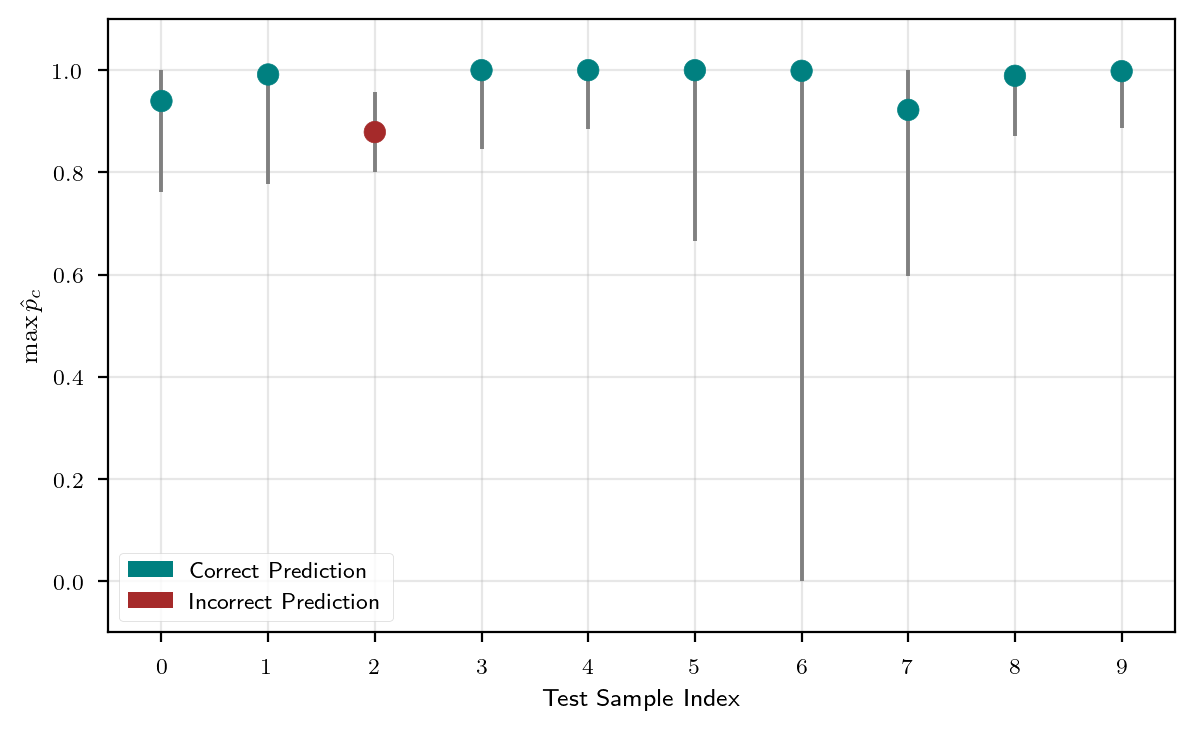

In [18]:
plt.figure(figsize=base_figure_size)

max_probs = [np.max(prob) for prob in nwc_probabilities]
x_indices = np.arange(len(max_probs))

# Create colors based on prediction correctness
colors = ['teal' if pred == y_test[i] else 'brown' for i, pred in enumerate(nwc_predictions)]

lower_errors = [min(cert, prob) for cert, prob in zip(nwc_certainties, max_probs)]
upper_errors = [min(cert, 1.0 - prob) for cert, prob in zip(nwc_certainties, max_probs)]  

plt.errorbar(x_indices, max_probs, yerr=[lower_errors, upper_errors], fmt='none', capsize=5, 
             markersize=8, ecolor='gray')

# Color the markers
plt.scatter(x_indices, max_probs, c=colors, s=60, zorder=5)

# Create legend handles for correct and incorrect predictions
legend_elements = [patches.Patch(facecolor='teal', label='Correct Prediction'), patches.Patch(facecolor='brown', label='Incorrect Prediction')]

plt.xlabel('Test Sample Index')
plt.ylabel(r'$\max \hat{p}_c$')
# plt.title('Regular NWC: Maximum Probability with Certainty Bounds')
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.xlim(-0.5, len(max_probs) - 0.5)
plt.xticks(x_indices)
plt.legend(handles=legend_elements)
plt.tight_layout()
# plt.savefig('results/regular_nwc.pgf', bbox_inches='tight')

# tikz.clean_figure()
# tikz.save('results/figures/regular_nwc.tex')
plt.show()


## Running the classifier on the full dataset

Here, we train the classifier on the entire training set and evaluate them on the entire sample of 27000 testing samples.

In [19]:
"""
FULL DATASET EVALUATION AND VISUALIZATION FOR REGULAR NWC
"""
# Load the entire dataset
full_dataset = load_ecg_data_truncated(n_train=87554, n_test=21892, stratified=False)
x_train_full = full_dataset['x_train']
y_train_full = full_dataset['y_train_one_hot']
x_test_full = full_dataset['x_test']
y_test_full = full_dataset['y_test']

# Define class labels for plotting
class_labels = {
    0: 'N (Normal)',
    1: 'S (Supraventricular)',
    2: 'V (Ventricular)',
    3: 'F (Fusion)',
    4: 'Q (Unclassifiable)'
}

# Initialize the regular Nadaraya-Watson Classifier
nwc_full = NadarayaWatsonClassifier(
    bandwidth=lamda,
    lipschitz_constant=L,
    kernel=K_epanechnikov
)

print(f"\nStarting prediction on all {len(x_test_full)} test samples...")
start_time = perf_counter()

full_predictions = []
full_probabilities = []
full_certainties = []

BOUND_THRESHOLD = 0.5

type_i_errors = collections.Counter()
type_ii_errors = collections.Counter()


for i in range(len(x_test_full)):
    probs, bounds = nwc_full.predict(x_test_full[i], x_train_full, y_train_full)
    predicted_class = np.argmax(probs)
    
    full_predictions.append(predicted_class)
    full_probabilities.append(probs)
    full_certainties.append(bounds)

    true_class = y_test_full[i]

    if predicted_class != true_class: 
        type_i_errors[true_class] += 1
    elif bounds > BOUND_THRESHOLD:
        type_ii_errors[true_class] += 1

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{len(x_test_full)} samples...")

end_time = perf_counter()
print(f"\nPrediction finished in {end_time - start_time:.2f} seconds.")

/var/folders/45/dqh1kb3n78b0rdqbbd1ql8s40000gn/T/ipykernel_7647/1464991154.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df_sampled = mitbih_train_df.groupby(187, group_keys=False).apply(


Loaded 87554 training samples and 21892 testing samples.
Training data shape: (87554, 100)
Test data shape: (21892, 100)

Starting prediction on all 21892 test samples...
  Processed 100/21892 samples...
  Processed 200/21892 samples...
  Processed 300/21892 samples...
  Processed 400/21892 samples...
  Processed 500/21892 samples...
  Processed 600/21892 samples...
  Processed 700/21892 samples...
  Processed 800/21892 samples...
  Processed 900/21892 samples...
  Processed 1000/21892 samples...
  Processed 1100/21892 samples...
  Processed 1200/21892 samples...
  Processed 1300/21892 samples...
  Processed 1400/21892 samples...
  Processed 1500/21892 samples...
  Processed 1600/21892 samples...
  Processed 1700/21892 samples...
  Processed 1800/21892 samples...
  Processed 1900/21892 samples...
  Processed 2000/21892 samples...
  Processed 2100/21892 samples...
  Processed 2200/21892 samples...
  Processed 2300/21892 samples...
  Processed 2400/21892 samples...
  Processed 2500/21892

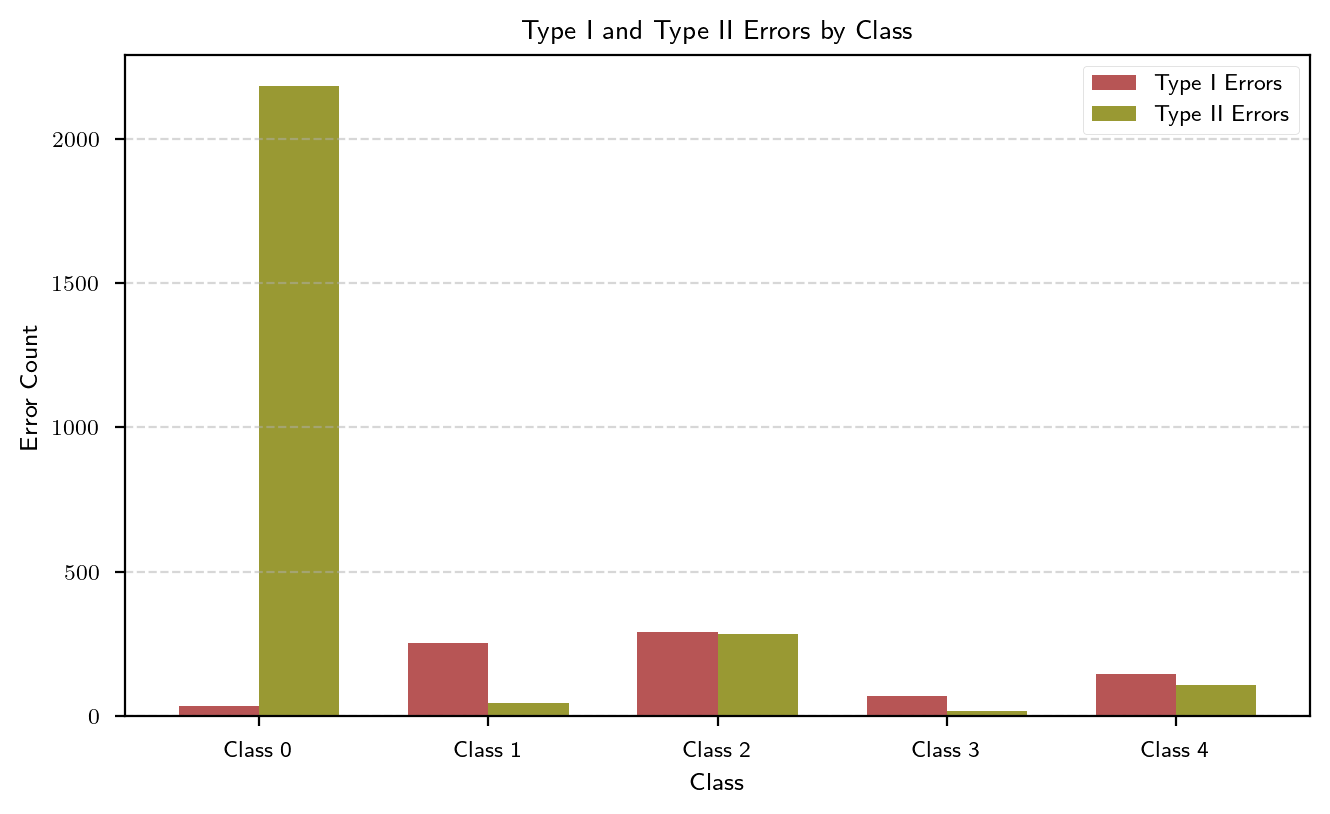

In [20]:
classes = list(range(5))  # Assuming 5 classes
type_i_counts = [type_i_errors[c] for c in classes]
type_ii_counts = [type_ii_errors[c] for c in classes]

plt.figure(figsize=set_figure_size(page_width_pt, 1.))
bar_width = 0.35
x = np.arange(len(classes))

plt.bar(x - bar_width / 2, type_i_counts, bar_width, label='Type I Errors', color='brown', alpha=0.8)
plt.bar(x + bar_width / 2, type_ii_counts, bar_width, label='Type II Errors', color='olive', alpha=0.8)

plt.xlabel('Class')
plt.ylabel('Error Count')
plt.title('Type I and Type II Errors by Class')
plt.xticks(x, [f'Class {c}' for c in classes])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

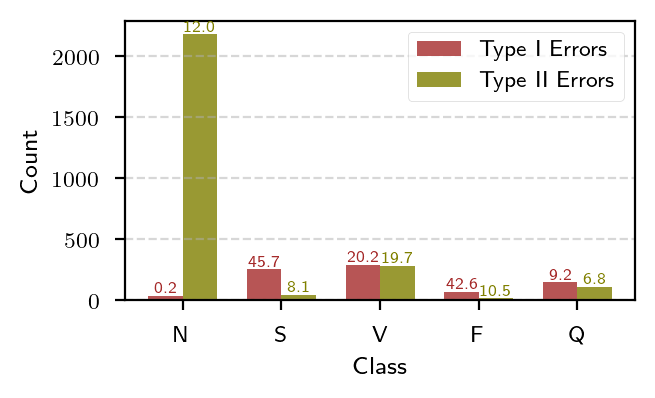

In [21]:
# Calculate total instances for each class in the test set
total_instances = collections.Counter(y_test_full)

# Calculate Type I and Type II error percentages
type_i_percentages = [(type_i_errors[c] / total_instances[c]) * 100 if total_instances[c] > 0 else 0 for c in classes]
type_ii_percentages = [(type_ii_errors[c] / total_instances[c]) * 100 if total_instances[c] > 0 else 0 for c in classes]

# Plot Type I and Type II error counts
plt.figure(figsize=set_figure_size(page_width_pt, 0.5))
bar_width = 0.35
x = np.arange(len(classes))

plt.bar(x - bar_width / 2, type_i_counts, bar_width, label='Type I Errors', color='brown', alpha=0.8)
plt.bar(x + bar_width / 2, type_ii_counts, bar_width, label='Type II Errors', color='olive', alpha=0.8)

# Add percentages as text above the bars
for i, (type_i_count, type_ii_count) in enumerate(zip(type_i_counts, type_ii_counts)):
    plt.text(i - bar_width / 2, type_i_count + 1, f"{type_i_percentages[i]:.1f}%", ha='center', va='bottom', fontsize=6, color='brown')
    plt.text(i + bar_width / 2, type_ii_count + 1, f"{type_ii_percentages[i]:.1f}%", ha='center', va='bottom', fontsize=6, color='olive')

# Add labels and legend
plt.xlabel('Class')
plt.ylabel('Count')
# plt.title('Type I and Type II Errors by Class (Counts and Percentages)')
plt.xticks(x, ['N', 'S', 'V', 'F', 'Q'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/type_errors_by_class.pgf')
# plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/type_errors_by_class.pdf')
plt.show()

In [22]:
# Let's show raw figures so that we can report these in the rebuttals 
e1, e2 = np.array(type_i_counts), np.array(type_ii_counts)
conservative_accuracy = 1 - ((np.sum(e1) + np.sum(e2))/y_test_full.size)
print(conservative_accuracy)

# should this be compared with conditional kernel mean embeddings?

0.8429563310798465


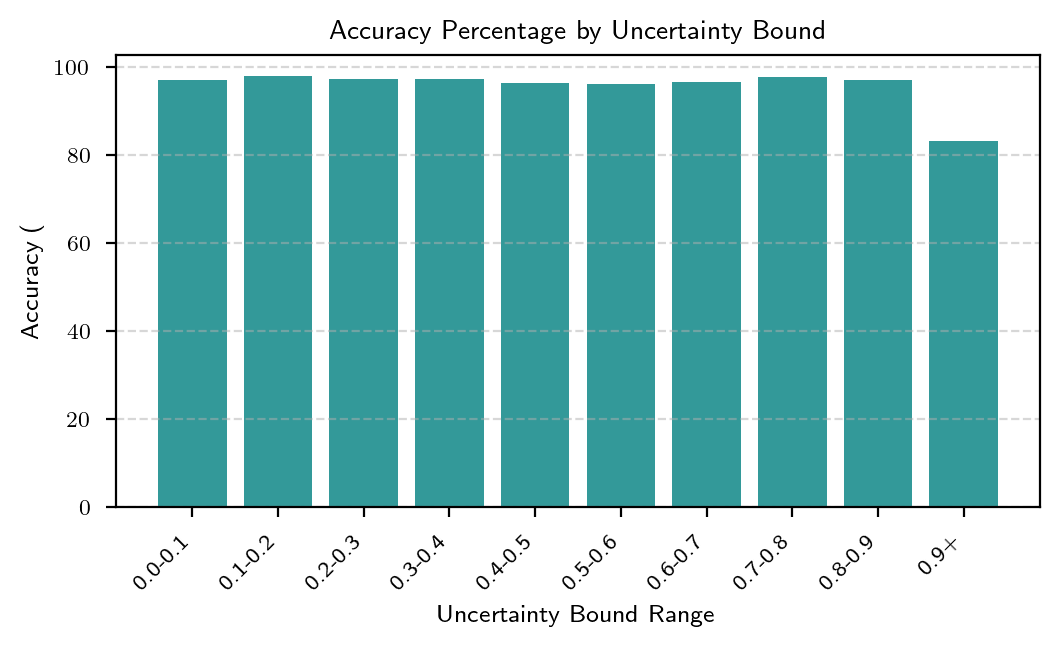

In [23]:
# --- Plot Accuracy Percentage by Uncertainty Bound ---

# Cap full_certainties at 1
full_certainties = np.minimum(full_certainties, 1.0)

# Define bins for uncertainty bounds with increments of 0.1
bins = np.arange(0, 1.1, 0.1)
bin_labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins) - 2)] + ["0.9+"]

# Initialize counters
correct_counts = np.zeros(len(bins) - 1, dtype=int)
total_counts = np.zeros(len(bins) - 1, dtype=int)

# Iterate through predictions and bounds
for pred, true, bound in zip(full_predictions, y_test_full, full_certainties):
    bin_idx = np.digitize(bound, bins) - 1
    bin_idx = min(bin_idx, len(correct_counts) - 1)
    total_counts[bin_idx] += 1
    if pred == true:
        correct_counts[bin_idx] += 1

# Calculate accuracy percentage for each bin
accuracy_percent = np.array([
    (correct_counts[i] / total_counts[i] * 100) if total_counts[i] > 0 else 0
    for i in range(len(correct_counts))
])

# --- Plotting ---
plt.figure(figsize=set_figure_size(page_width_pt, 0.8))
x = np.arange(len(bin_labels))
plt.bar(x, accuracy_percent, color='teal', alpha=0.8)
plt.xticks(x, bin_labels, rotation=45, ha="right")
plt.xlabel("Uncertainty Bound Range")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Percentage by Uncertainty Bound")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

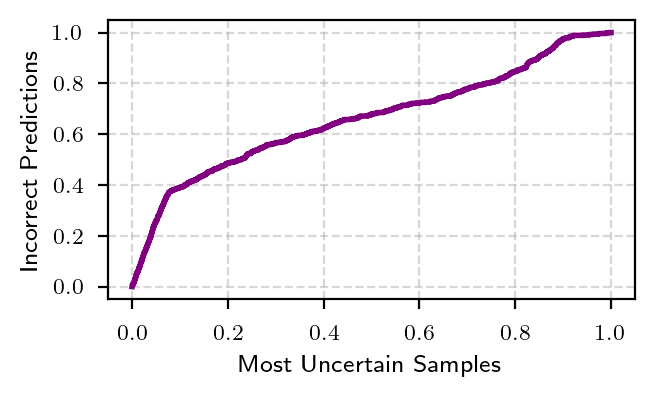

In [24]:
full_certainties_arr = np.array(full_certainties)
full_predictions_arr = np.array(full_predictions)
y_test_full_arr = np.array(y_test_full)

# Sort indices by uncertainty (descending: most uncertain first)
sorted_indices = np.argsort(-full_certainties_arr)

# Mask for incorrect predictions
incorrect_mask = (full_predictions_arr != y_test_full_arr)
total_errors = np.sum(incorrect_mask)

# Track cumulative errors captured as we flag more uncertain samples
cumulative_errors = np.cumsum(incorrect_mask[sorted_indices])
num_samples = len(full_certainties_arr)

# Fraction of flagged samples and fraction of errors captured
fraction_flagged = np.arange(1, num_samples + 1) / num_samples
fraction_errors_captured = cumulative_errors / total_errors

plt.figure(figsize=set_figure_size(page_width_pt, 0.5))
plt.plot(fraction_flagged, fraction_errors_captured, color='purple', lw=2)
plt.xlabel("Most Uncertain Samples")
plt.ylabel("Incorrect Predictions")
# plt.title("Cumulative Recall Curve: Error Capture by Uncertainty")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/crc.pgf')
# plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/crc.pdf')
plt.show()

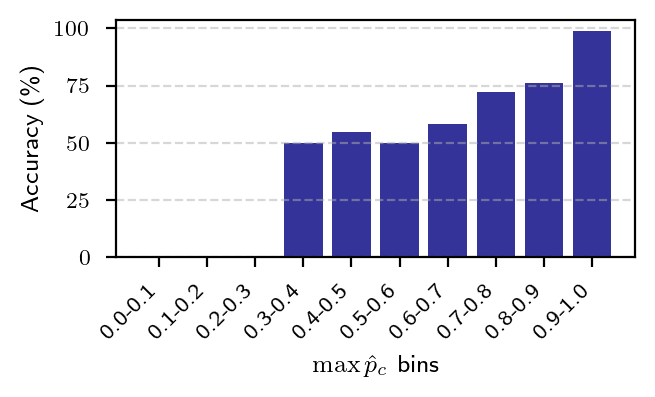

In [25]:
# --- Plot Expected Calibration Error (ECE): Accuracy vs. Predicted Probability ---

# Get max probability for each sample
max_probs = np.array([np.max(prob) for prob in full_probabilities])

# Define bins from 0 to 1 in steps of 0.1
bins = np.arange(0, 1.1, 0.1)
bin_labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins) - 1)]

# Initialize counters
bin_correct = np.zeros(len(bins) - 1, dtype=int)
bin_total = np.zeros(len(bins) - 1, dtype=int)

# Bin samples and count accuracy
for prob, pred, true in zip(max_probs, full_predictions, y_test_full):
    bin_idx = np.digitize(prob, bins) - 1
    if 0 <= bin_idx < len(bin_correct):
        bin_total[bin_idx] += 1
        if pred == true:
            bin_correct[bin_idx] += 1

# Calculate accuracy per bin
bin_accuracy = np.array([
    (bin_correct[i] / bin_total[i] * 100) if bin_total[i] > 0 else 0
    for i in range(len(bin_correct))
])

# --- Plotting ---
plt.figure(figsize=set_figure_size(page_width_pt, 0.5))
x = np.arange(len(bin_labels))
plt.bar(x, bin_accuracy, color='navy', alpha=0.8)
plt.xticks(x, bin_labels, rotation=45, ha="right")
plt.xlabel("$\max \hat{p}_c$ bins")
plt.ylabel("Accuracy (\%)")
# plt.title("Expected Calibration Error: Accuracy vs. Predicted Probability")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/ece.pgf')
# plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/ece.pdf')
plt.show()

In [26]:
# --- Evaluation ---
# class_labels = {
#     0: 'Normal', 
#     1: 'Abnormal'
# }

print("\n--- Classification Report (Full Test Set) ---")
print(classification_report(y_test_full, full_predictions, target_names=[class_labels[i] for i in range(5)], zero_division=0))

print("\n--- Confusion Matrix (Full Test Set) ---")
print(confusion_matrix(y_test_full, full_predictions))


--- Classification Report (Full Test Set) ---
                      precision    recall  f1-score   support

          N (Normal)       0.96      1.00      0.98     18118
S (Supraventricular)       0.93      0.54      0.69       556
     V (Ventricular)       0.97      0.80      0.88      1448
          F (Fusion)       0.75      0.57      0.65       162
  Q (Unclassifiable)       0.99      0.91      0.95      1608

            accuracy                           0.96     21892
           macro avg       0.92      0.76      0.83     21892
        weighted avg       0.96      0.96      0.96     21892


--- Confusion Matrix (Full Test Set) ---
[[18081    17    11     6     3]
 [  250   302     2     2     0]
 [  253     6  1156    23    10]
 [   56     0    13    93     0]
 [  144     0     4     0  1460]]


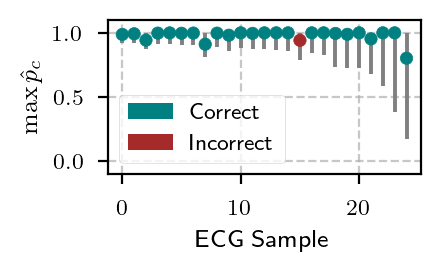

In [27]:
# --- Visualization ---
n_plot_samples = 25
plot_indices = rng.choice(len(x_test_full), n_plot_samples, replace=False)

# Get data for the selected samples
max_probs_plot = [max(full_probabilities[i]) for i in plot_indices]
certainties_plot = [full_certainties[i] for i in plot_indices]
y_test_plot = [y_test_full[i] for i in plot_indices]
predictions_plot = [full_predictions[i] for i in plot_indices]

sorted_data = sorted(zip(certainties_plot, max_probs_plot, y_test_plot, predictions_plot), key=lambda x: x[0])
certainties_sorted, max_probs_sorted, y_test_sorted, predictions_sorted = zip(*sorted_data)

plt.figure(figsize=set_figure_size(page_width_pt, 0.35))
colors = ['teal' if y_test_sorted[i] == predictions_sorted[i] else 'brown' for i in range(n_plot_samples)]
certainties_sorted, max_probs_sorted = np.round(certainties_sorted, 6), np.round(max_probs_sorted, 6)
lower_errors = [min(cert, prob) for cert, prob in zip(certainties_sorted, max_probs_sorted)]
upper_errors = [min(cert, 1.0 - prob) for cert, prob in zip(certainties_sorted, max_probs_sorted)]

plt.errorbar(range(n_plot_samples), max_probs_sorted, yerr=[lower_errors, upper_errors], fmt='o', capsize=5, markersize=0, ecolor='gray')

# for i, (x, y, color) in enumerate(zip(range(n_plot_samples), max_probs_sorted, colors)):
plt.scatter(range(n_plot_samples), max_probs_sorted, c=colors, s=20, zorder=5)

legend_elements = [patches.Patch(facecolor='teal', label='Correct'), patches.Patch(facecolor='brown', label='Incorrect')]
plt.legend(handles=legend_elements)
plt.ylim([-0.1, 1.1])
plt.xlabel(f"ECG Sample")
plt.ylabel(r"$\max \hat{p}_c$")
# plt.title(f"Regular NWC Certainty on Full Test Set (Bandwidth: {lamda}) - Sorted by Bound Strength")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# tikz.clean_figure()
# tikz.save('results/figures/localized_predictions_and_confidence.tex')
# plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/regular_smaller.pgf')
# plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/regular_smaller.pgf')
# plt.savefig('results/figures/regular_predictions_and_confidence.pgf')
# plt.savefig('results/figures/regular_predictions_and_confidence.pdf')
plt.show()


In [28]:
"""
FULL DATASET EVALUATION AND VISUALIZATION FOR LOCALIZED NWC
"""
# Load the entire dataset
# full_dataset = load_ecg_data_truncated(n_train=87554, n_test=21892, stratified=False)
# x_train_full = full_dataset['x_train']
# y_train_full = full_dataset['y_train_one_hot']
# x_test_full = full_dataset['x_test']
# y_test_full = full_dataset['y_test']

# Define class labels for plotting
class_labels = {
    0: 'N (Normal)',
    1: 'S (Supraventricular)',
    2: 'V (Ventricular)',
    3: 'F (Fusion)',
    4: 'Q (Unclassifiable)'
}

# Initialize the regular Nadaraya-Watson Classifier
localized_nwc_full = LocalizedNWC(
    bandwidth=lamda,
    lipschitz_constant=L,
    kernel=K_epanechnikov
)

localized_nwc_full.fit(x_train_full, y_train_full)

print(f"\nStarting prediction on all {len(x_test_full)} test samples...")
start_time = perf_counter()

localized_predictions = []
localized_probabilities = []
localized_certainties = []

for i in range(len(x_test_full)):
    probs, bounds = localized_nwc_full.predict(x_test_full[i], k=CONFIG['evaluation']['localized_k'])
    predicted_class = np.argmax(probs)
    
    localized_predictions.append(predicted_class)
    localized_probabilities.append(probs)
    localized_certainties.append(bounds)
    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{len(x_test_full)} samples...")

end_time = perf_counter()
print(f"\nPrediction finished in {end_time - start_time:.2f} seconds.")


Starting prediction on all 21892 test samples...
  Processed 100/21892 samples...
  Processed 200/21892 samples...
  Processed 300/21892 samples...
  Processed 400/21892 samples...
  Processed 500/21892 samples...
  Processed 600/21892 samples...
  Processed 700/21892 samples...
  Processed 800/21892 samples...
  Processed 900/21892 samples...
  Processed 1000/21892 samples...
  Processed 1100/21892 samples...
  Processed 1200/21892 samples...
  Processed 1300/21892 samples...
  Processed 1400/21892 samples...
  Processed 1500/21892 samples...
  Processed 1600/21892 samples...
  Processed 1700/21892 samples...
  Processed 1800/21892 samples...
  Processed 1900/21892 samples...
  Processed 2000/21892 samples...
  Processed 2100/21892 samples...
  Processed 2200/21892 samples...
  Processed 2300/21892 samples...
  Processed 2400/21892 samples...
  Processed 2500/21892 samples...
  Processed 2600/21892 samples...
  Processed 2700/21892 samples...
  Processed 2800/21892 samples...
  Proce

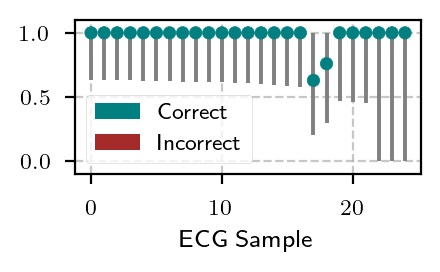

In [29]:
# --- Visualization ---
n_plot_samples = 25
plot_indices = rng.choice(len(x_test_full), n_plot_samples, replace=False)

# Get data for the selected samples
max_probs_plot = [max(localized_probabilities[i]) for i in plot_indices]
certainties_plot = [localized_certainties[i] for i in plot_indices]
y_test_plot = [y_test_full[i] for i in plot_indices]
predictions_plot = [localized_predictions[i] for i in plot_indices]

sorted_data = sorted(zip(certainties_plot, max_probs_plot, y_test_plot, predictions_plot), key=lambda x: x[0])
certainties_sorted, max_probs_sorted, y_test_sorted, predictions_sorted = zip(*sorted_data)

plt.figure(figsize=set_figure_size(page_width_pt, 0.35))
colors = ['teal' if y_test_sorted[i] == predictions_sorted[i] else 'brown' for i in range(n_plot_samples)]
certainties_sorted, max_probs_sorted = np.round(certainties_sorted, 6), np.round(max_probs_sorted, 6)
lower_errors = [min(cert, prob) for cert, prob in zip(certainties_sorted, max_probs_sorted)]
upper_errors = [min(cert, 1.0 - prob) for cert, prob in zip(certainties_sorted, max_probs_sorted)]

plt.errorbar(range(n_plot_samples), max_probs_sorted, yerr=[lower_errors, upper_errors], fmt='o', capsize=5, markersize=0, ecolor='gray')

# for i, (x, y, color) in enumerate(zip(range(n_plot_samples), max_probs_sorted, colors)):
plt.scatter(range(n_plot_samples), max_probs_sorted, c=colors, s=20, zorder=5)

legend_elements = [patches.Patch(facecolor='teal', label='Correct'), patches.Patch(facecolor='brown', label='Incorrect')]
plt.legend(handles=legend_elements)
plt.ylim([-0.1, 1.1])
plt.xlabel(f"ECG Sample")
# plt.ylabel(r"$\max \hat{p}_c$")
# plt.title(f"Localized NWC Certainty on Full Test Set (Bandwidth: {lamda}) - Sorted by Bound Strength")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# tikz.clean_figure()
# tikz.save('results/figures/localized_predictions_and_confidence.tex')
# plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/localized_predictions_smaller.pgf')
# plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/localized_predictions_smaller.pdf')
# plt.savefig('/aistats_results/figures/localized_predictions_and_confidence_smaller.pgf')
# plt.savefig('/aistats_results/figures/localized_predictions_and_confidence_smaller.pdf')
plt.show()


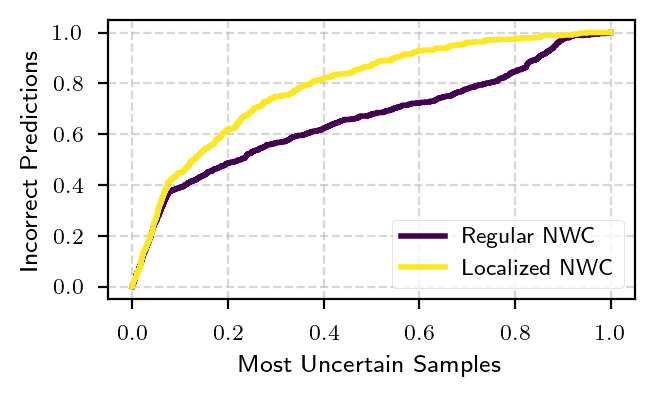

In [32]:
"""
CUMULATIVE RECALL CURVE: REGULAR VS LOCALIZED CLASSIFIER
"""

# Convert to numpy arrays for easier indexing
full_certainties_arr = np.array(full_certainties)
full_predictions_arr = np.array(full_predictions)

localized_certainties_arr = np.array(localized_certainties)
localized_predictions_arr = np.array(localized_predictions)

y_test_full_arr = np.array(y_test_full)

# Optionally cap the uncertainties at 1 for stability
full_certainties_arr = np.minimum(full_certainties_arr, 1.0)
localized_certainties_arr = np.minimum(localized_certainties_arr, 1.0)


def compute_crc(certainties, predictions, y_true):
    """Compute cumulative recall curve (CRC) for a classifier.

    certainties: array of uncertainty bounds (larger = more uncertain)
    predictions: predicted class indices
    y_true: true class indices
    """
    # Sort indices by uncertainty (descending: most uncertain first)
    sorted_indices = np.argsort(-certainties)

    # Mask for incorrect predictions
    incorrect_mask = (predictions != y_true)
    total_errors = np.sum(incorrect_mask)

    num_samples = len(certainties)
    fraction_flagged = np.arange(1, num_samples + 1) / num_samples

    if total_errors == 0:
        # Avoid division by zero: no errors to capture
        return fraction_flagged, np.zeros_like(fraction_flagged)

    # Track cumulative errors captured as we flag more uncertain samples
    cumulative_errors = np.cumsum(incorrect_mask[sorted_indices])
    fraction_errors_captured = cumulative_errors / total_errors

    return fraction_flagged, fraction_errors_captured


# CRC for regular NWC
fraction_flagged_full, fraction_errors_captured_full = compute_crc(
    full_certainties_arr, full_predictions_arr, y_test_full_arr
)

# CRC for localized NWC
fraction_flagged_loc, fraction_errors_captured_loc = compute_crc(
    localized_certainties_arr, localized_predictions_arr, y_test_full_arr
)

plt.figure(figsize=set_figure_size(page_width_pt, 0.5))

# Colorblind-friendly colors (dark violet & yellow-like)
full_color = "#440154"       # dark violet
localized_color = "#FDE725"  # yellow

plt.plot(
    fraction_flagged_full,
    fraction_errors_captured_full,
    color=full_color,
    lw=2,
    label="Regular NWC",
)

plt.plot(
    fraction_flagged_loc,
    fraction_errors_captured_loc,
    color=localized_color,
    lw=2,
    label="Localized NWC",
)

plt.xlabel("Most Uncertain Samples")
plt.ylabel("Incorrect Predictions")
# plt.title("Cumulative Recall Curve: Error Capture by Uncertainty")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/crc_both.pgf")
plt.savefig("/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/crc_both.pdf")
plt.show()

In [28]:
"""
LOCAL POLYNOMIAL CLASSIFIER (LOESS) EVALUATION
"""

# --- Configuration for Baseline ---
# Degree 1 = Local Linear, Degree 2 = Local Quadratic
POLY_DEGREE = 1 
# Limit evaluation samples because LOESS is computationally expensive
N_EVAL_LIMIT = 2000

print(f"\n--- Evaluating Local Polynomial Classifier (Degree {POLY_DEGREE}) ---")
print(f"Note: Limiting evaluation to first {N_EVAL_LIMIT} samples for speed.")

# Subset data for evaluation
x_test_subset = x_test_full[:N_EVAL_LIMIT]
y_test_subset = y_test_full[:N_EVAL_LIMIT]

# Initialize Model
lpc = LocalPolynomialClassifier(
    bandwidth=lamda,  # Using same bandwidth as NWC for fair comparison
    degree=POLY_DEGREE,
    reg_param=1e-4,
    kernel=K_epanechnikov
)

# Run Prediction & Timing
start_time = perf_counter()

lpc_predictions = []
lpc_probabilities = []

# Loop prediction (predict one by one)
for i in range(len(x_test_subset)):
    probs, _ = lpc.predict(x_test_subset[i], x_train_full, y_train_full)
    lpc_predictions.append(np.argmax(probs))
    lpc_probabilities.append(probs)
    
    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{len(x_test_subset)} samples...")

end_time = perf_counter()
lpc_total_time = end_time - start_time
lpc_avg_time = lpc_total_time / len(x_test_subset)

print(f"\nPrediction finished in {lpc_total_time:.2f} seconds.")
print(f"Average Inference Time per Sample: {lpc_avg_time:.4f} seconds")

# --- Metrics ---
lpc_predictions = np.array(lpc_predictions)
# Convert one-hot test labels back to indices if necessary, or use y_test if it's already indices
# Assuming y_test_full contains indices based on previous cells
y_true_subset = y_test_full[:N_EVAL_LIMIT] 

print(f"\n--- Classification Report (LOESS Degree {POLY_DEGREE}) ---")
print(classification_report(y_true_subset, lpc_predictions, 
                            target_names=[class_labels[i] for i in range(5)], 
                            zero_division=0))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_true_subset, lpc_predictions))


--- Evaluating Local Polynomial Classifier (Degree 1) ---
Note: Limiting evaluation to first 2000 samples for speed.
  Processed 100/2000 samples...
  Processed 200/2000 samples...
  Processed 300/2000 samples...
  Processed 400/2000 samples...
  Processed 500/2000 samples...
  Processed 600/2000 samples...
  Processed 700/2000 samples...
  Processed 800/2000 samples...
  Processed 900/2000 samples...
  Processed 1000/2000 samples...
  Processed 1100/2000 samples...
  Processed 1200/2000 samples...
  Processed 1300/2000 samples...
  Processed 1400/2000 samples...
  Processed 1500/2000 samples...
  Processed 1600/2000 samples...
  Processed 1700/2000 samples...
  Processed 1800/2000 samples...
  Processed 1900/2000 samples...
  Processed 2000/2000 samples...

Prediction finished in 154.95 seconds.
Average Inference Time per Sample: 0.0775 seconds

--- Classification Report (LOESS Degree 1) ---
                      precision    recall  f1-score   support

          N (Normal)       0.9

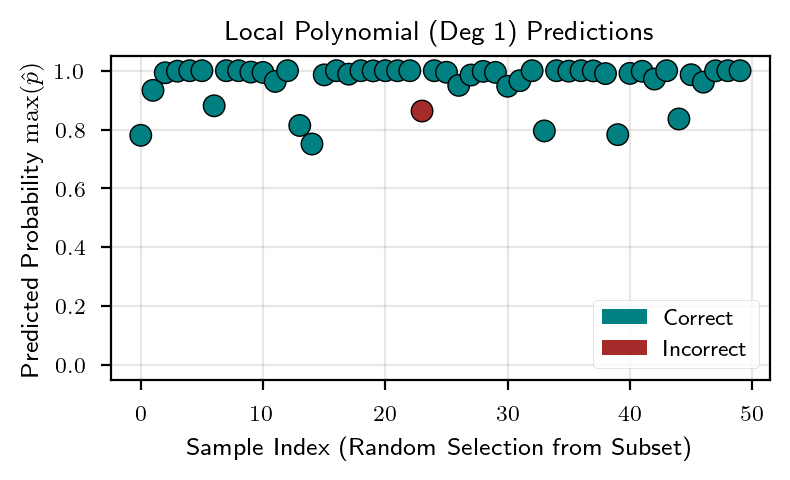

In [ ]:
# --- Visualization (50 Random Samples) ---
plt.figure(figsize=set_figure_size(page_width_pt, 0.6))

n_plot = 50
# Randomly select indices from the subset we just evaluated
plot_indices = rng.choice(len(x_test_subset), n_plot, replace=False)

# Extract max probabilities and predictions
plot_probs = [np.max(lpc_probabilities[i]) for i in plot_indices]
plot_preds = [lpc_predictions[i] for i in plot_indices]
plot_true = [y_true_subset[i] for i in plot_indices]

# Color coding: Teal = Correct, Brown = Incorrect
colors = ['teal' if p == t else 'brown' for p, t in zip(plot_preds, plot_true)]
x_indices = np.arange(n_plot)

# Create Scatter Plot
plt.scatter(x_indices, plot_probs, c=colors, s=60, zorder=5, edgecolors='k', linewidth=0.5)

# Legend
legend_elements = [
    patches.Patch(facecolor='teal', label='Correct'),
    patches.Patch(facecolor='brown', label='Incorrect')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.ylabel(r'Predicted Probability $\max(\hat{p})$')
plt.xlabel('Sample Index (Random Selection from Subset)')
plt.title(f'Local Polynomial (Deg {POLY_DEGREE}) Predictions')
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
from sklearn.metrics import accuracy_score


acc = accuracy_score(y_true_subset, lpc_predictions)

print(f"\n\nPrediction finished in {lpc_total_time:.2f}s (Avg: {lpc_avg_time:.4f}s/sample)")
print(f"Accuracy: {acc:.4f}")

print(f"\n--- Classification Report (LOESS Degree {POLY_DEGREE}) ---")
print(classification_report(y_true_subset, lpc_predictions, 
                            target_names=[class_labels[i] for i in range(5)], 
                            zero_division=0))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_true_subset, lpc_predictions))



Prediction finished in 152.02s (Avg: 0.0760s/sample)
Accuracy: 0.9760

--- Classification Report (LOESS Degree 1) ---
                      precision    recall  f1-score   support

          N (Normal)       0.98      1.00      0.99      1648
S (Supraventricular)       0.92      0.77      0.84        64
     V (Ventricular)       0.97      0.86      0.91       120
          F (Fusion)       0.89      0.67      0.76        12
  Q (Unclassifiable)       1.00      0.94      0.97       156

            accuracy                           0.98      2000
           macro avg       0.95      0.85      0.89      2000
        weighted avg       0.98      0.98      0.98      2000

--- Confusion Matrix ---
[[1645    3    0    0    0]
 [  13   49    1    1    0]
 [  17    0  103    0    0]
 [   3    0    1    8    0]
 [   7    1    1    0  147]]


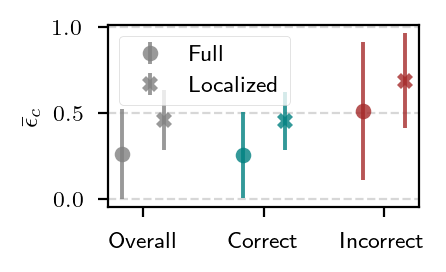

In [54]:
# Convert to numpy arrays for easier indexing
full_certainties_arr = np.array(full_certainties)
full_predictions_arr = np.array(full_predictions)
localized_certainties_arr = np.array(localized_certainties)
localized_predictions_arr = np.array(localized_predictions)
y_test_full_arr = np.array(y_test_full)

# Capping the uncertainties at 1
full_certainties_arr = np.minimum(full_certainties_arr, 1.)
localized_certainties_arr = np.minimum(localized_certainties_arr, 1.)

# Masks for correct and incorrect predictions
full_correct_mask = (full_predictions_arr == y_test_full_arr)
full_incorrect_mask = ~full_correct_mask

localized_correct_mask = (localized_predictions_arr == y_test_full_arr)
localized_incorrect_mask = ~localized_correct_mask

# Compute means and variances for full certainties
full_mean_overall = np.mean(full_certainties_arr)
full_var_overall = np.var(full_certainties_arr)

full_mean_correct = np.mean(full_certainties_arr[full_correct_mask])
full_var_correct = np.var(full_certainties_arr[full_correct_mask])

full_mean_incorrect = np.mean(full_certainties_arr[full_incorrect_mask])
full_var_incorrect = np.var(full_certainties_arr[full_incorrect_mask])

# Compute means and variances for localized certainties
localized_mean_overall = np.mean(localized_certainties_arr)
localized_var_overall = np.var(localized_certainties_arr)

localized_mean_correct = np.mean(localized_certainties_arr[localized_correct_mask])
localized_var_correct = np.var(localized_certainties_arr[localized_correct_mask])

localized_mean_incorrect = np.mean(localized_certainties_arr[localized_incorrect_mask])
localized_var_incorrect = np.var(localized_certainties_arr[localized_incorrect_mask])

# Bar plot
labels = ['Overall', 'Correct', 'Incorrect']
x = np.arange(len(labels))
width = 0.35

# Data for full and localized certainties
full_means = [full_mean_overall, full_mean_correct, full_mean_incorrect]
full_variances = [full_var_overall, full_var_correct, full_var_incorrect]

localized_means = [localized_mean_overall, localized_mean_correct, localized_mean_incorrect]
localized_variances = [localized_var_overall, localized_var_correct, localized_var_incorrect]

plt.figure(figsize=set_figure_size(page_width_pt, 0.35))
bar_colors = ['gray', 'teal', 'brown']

# Plot full certainties
for i, (mean, var) in enumerate(zip(full_means, full_variances)):
    plt.errorbar(i - width / 2, mean, yerr=np.sqrt(var), fmt='o', color=bar_colors[i], capsize=8, alpha=0.8, label='Full' if i == 0 else "")

# Plot localized certainties
for i, (mean, var) in enumerate(zip(localized_means, localized_variances)):
    plt.errorbar(i + width / 2, mean, yerr=np.sqrt(var), fmt='X', color=bar_colors[i], capsize=8, alpha=0.8, label='Localized' if i == 0 else "")

plt.xticks(x, labels)
plt.ylabel(r'$\bar{\epsilon} _c$')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()


plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/full_vs_localized_mean_bound_13.pgf')
plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/aistats_results/figures/full_vs_localized_mean_bound_13.pdf')

plt.show()


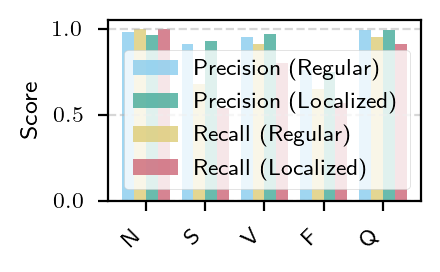

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Precision and recall values from the screenshots
precision_regular = [0.98, 0.91, 0.95, 0.76, 0.99]
recall_regular = [1.00, 0.68, 0.91, 0.65, 0.95]

precision_localized = [0.96, 0.93, 0.97, 0.75, 0.99]
recall_localized = [1.00, 0.54, 0.80, 0.57, 0.91]

# Class labels
class_labels = ['N', 'S', 'V', 'F', 'Q']

# Bar chart setup
x = np.arange(len(class_labels))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=set_figure_size(page_width_pt, 0.35))

# Plot precision bars
ax.bar(x - 1.5 * width, precision_regular, width, label='Precision (Regular)', color='#88CCEE', alpha=0.8)
ax.bar(x + 0.5 * width, precision_localized, width, label='Precision (Localized)', color='#44AA99', alpha=0.8)

# Plot recall bars
ax.bar(x - 0.5 * width, recall_regular, width, label='Recall (Regular)', color='#DDCC77', alpha=0.8)
ax.bar(x + 1.5 * width, recall_localized, width, label='Recall (Localized)', color='#CC6677', alpha=0.8)

# Add labels, title, and legend
# ax.set_title('Precision and Recall for the Regular and Localized Classifiers')
ax.set_xticks(x)
ax.set_ylabel('Score')
ax.set_xticklabels(class_labels, rotation=45, ha="right")
ax.legend(loc='lower right')  # Set legend to appear at the bottom left

# Add grid for better readability
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# plt.savefig('results/figures/precision_recall.pgf')
# plt.savefig('results/figures/precision_recall.pdf')
plt.show()

In [ ]:
class_labels = {
    0: 'N (Normal)',
    1: 'S (Supraventricular)',
    2: 'V (Ventricular)',
    3: 'F (Fusion)',
    4: 'Q (Unclassifiable)'
}

# Select one sample from each class except for the last class
class_indices = {}
for class_id in range(4):  # Exclude the last class (class_id = 4)
    class_samples = np.where(y_test_full == class_id)[0]
    if len(class_samples) > 0:
        class_indices[class_id] = rng.choice(class_samples)

n_samples_to_show = len(class_indices)
selected_indices = list(class_indices.values())

n_cols = n_samples_to_show
n_rows = 2  # One row for waveforms, one row for probabilities
plt.figure(figsize=set_figure_size(page_width_pt, 0.9))

for plot_num, i in enumerate(selected_indices):
    # Plot ECG Signal
    plt.subplot(n_rows, n_cols, plot_num + 1)
    plt.plot(x_test_full[i])
    true_class_name = class_labels[y_test_full[i]]
    pred_class_name = class_labels[full_predictions[i]]
    color = 'teal' if y_test_full[i] == full_predictions[i] else 'brown'
    plt.title(f"True: {true_class_name}\nPred: {pred_class_name}", color=color)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel(r"$t$")
    plt.ylabel("Amplitude")

    # Plot Probability Bar Chart
    plt.subplot(n_rows, n_cols, n_cols + plot_num + 1)
    bar_colors = ['teal' if j == y_test_full[i] else 'lightgray' for j in range(5)]
    plt.bar([label.split(' ')[0] for label in class_labels.values()], full_probabilities[i], color=bar_colors)
    plt.ylim(0., 1.1)
    plt.ylabel(r"$\hat{p}_c$")
    # plt.xlabel("ECG Class")
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('results/figures/individual_ecg_waveforms_horizontal.pgf')
plt.savefig('results/figures/individual_ecg_waveforms_horizontal.pdf')
plt.show()
